### Initialize paths

In [1]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel/UDELData")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}

# T1W and T2w paths for later myelin calculation
t1w_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_deface.nii.gz"
t2w_path = udel_anatomy/f"U01_UDEL_{subid}_01_3DT2_norm.nii.gz"

# Brain mask
brainmask_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_slant_brainmask.nii.gz"

### Surface sampling

In [50]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter


cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


#mask_img = nib.load(str(brainmask_dir))
#mask_data = mask_img.get_fdata()
#mask_affine = mask_img.affine

#surface_brainmask = {hemi: mid_layers[hemi].interpolate_to_nodes(mask_data, mask_affine) for hemi in ["lh","rh"]}

#surface_brainmask = {hemi: surface_brainmask[hemi] > 0.5 for hemi in ["lh","rh"]}

# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine


#t1_masked = np.where(mask_data, t1_data, np.nan)
#t2_masked = np.where(mask_data, t2_data, np.nan)


valid = (t1_data > 0) & (t2_data > 0)

myelin_data = np.where(valid, t1_data/(t2_data + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}

#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}

thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [51]:
for hemi in ["lh","rh"]:
    arr=surface_myelin[hemi]
    print(hemi, np.min(arr), np.max(arr), np.mean(arr))

lh -2398.308425925616 525.9797095213344 0.5041213635397584
rh -88.70064074702577 268.28192951844795 0.5149783843283172


### Descriptive statistics and visualization 

In [52]:
import pandas as pd

stiff_min=99 #Pa (=0.099 kPa)

for hemi in ["lh","rh"]:
    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]

    #Check values
    print(f"Initial vertices {hemi.upper()}:",len(stiff), f"({len(myelin)== len(imag) & len(stiff)==len(curv)})")
    print(f"After filtering vertices {hemi.upper()}:",len(stiff_m), f"({len(myelin_m)== len(imag_m) & len(stiff_m)==len(curv_m)})")

    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
    })

df.describe()

    


Initial vertices LH: 158340 (True)
After filtering vertices LH: 152319 (True)
Initial vertices RH: 159948 (True)
After filtering vertices RH: 153716 (True)


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
count,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000
mean,-0.021281,2.393531,0.250125,2.833257,2.399141,1.074870,0.510986
std,0.160836,0.906560,5.548738,0.856127,0.884726,0.461676,1.503882
min,-0.643204,0.000000,-14.329679,0.099035,0.025242,0.000707,-88.700641
25%,-0.138074,1.960080,-4.011983,2.340931,1.831647,0.774613,0.424855
50%,0.001130,2.479377,-0.128173,2.808097,2.332951,1.115679,0.472612
75%,0.108364,2.973067,4.238065,3.352004,2.925332,1.391897,0.540640
max,0.430637,5.000000,16.251078,6.289461,6.239851,2.699844,268.281930


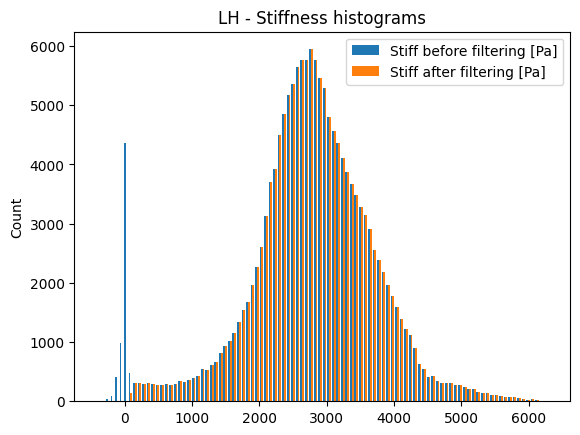

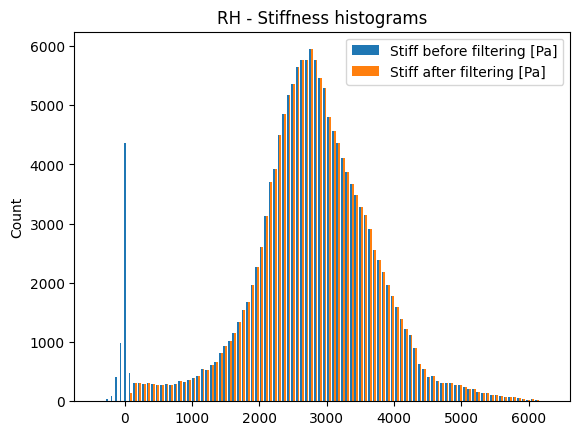

In [24]:

for hemi in ["lh","rh"]:
    plt.hist([stiff, stiff_m], bins=100, label=["Stiff before filtering [Pa]","Stiff after filtering [Pa]"])
    plt.ylabel("Count")
    plt.title(f"{hemi.upper()} - Stiffness histograms")
    plt.legend()
    plt.show()



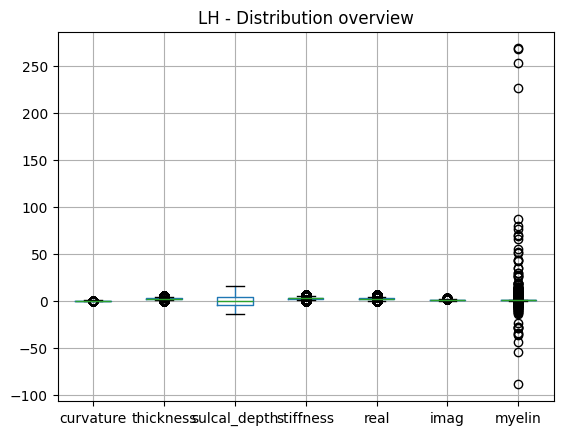

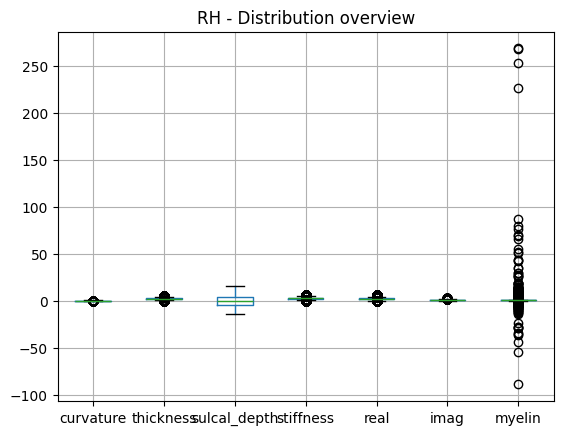

In [53]:
import matplotlib.pyplot as plt
for hemi in ["lh","rh"]:
    df.boxplot()
    plt.title(f"{hemi.upper()} - Distribution overview")
    plt.show()


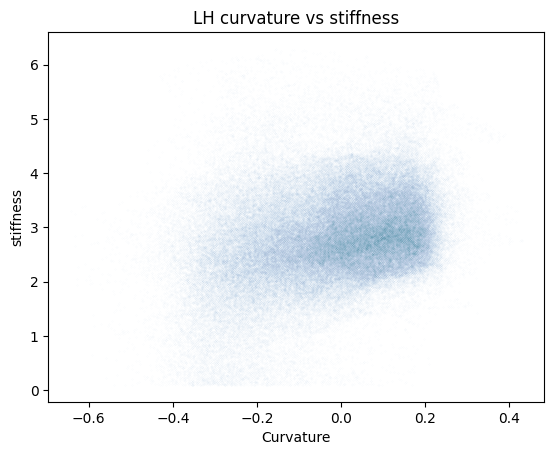

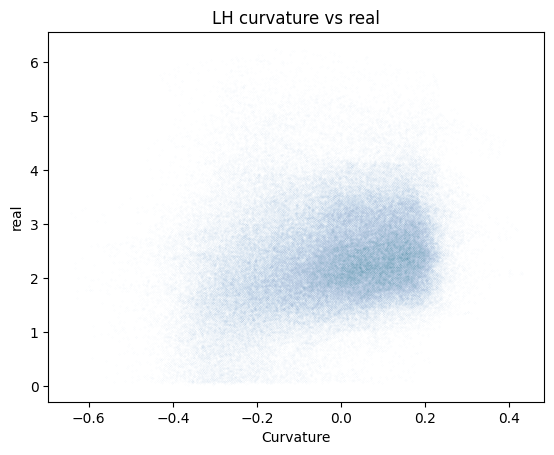

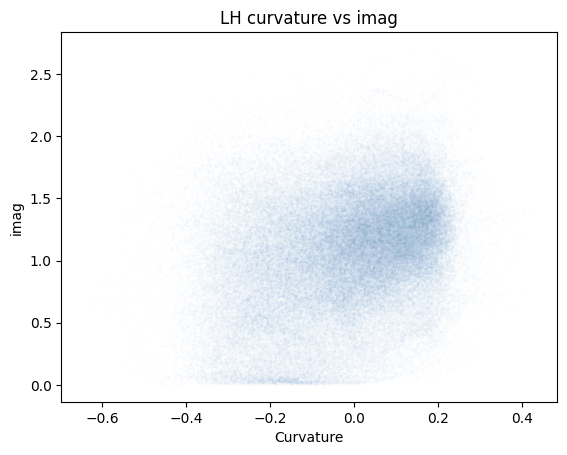

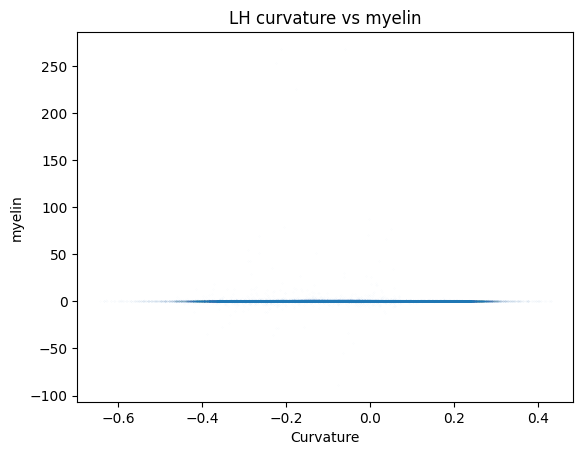

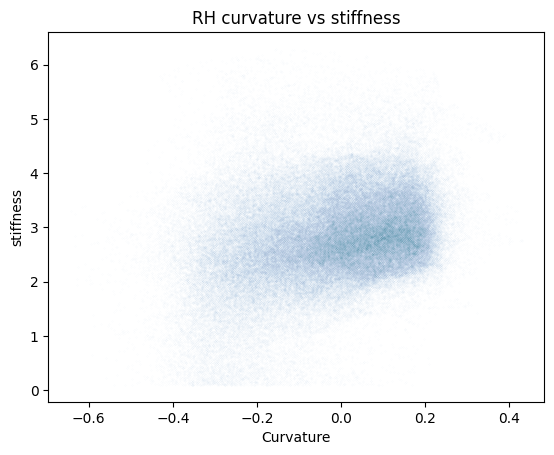

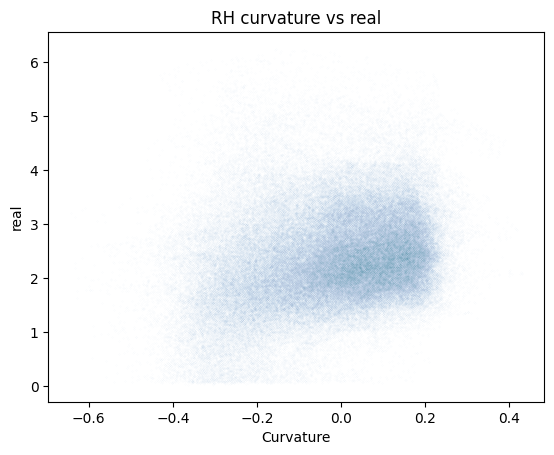

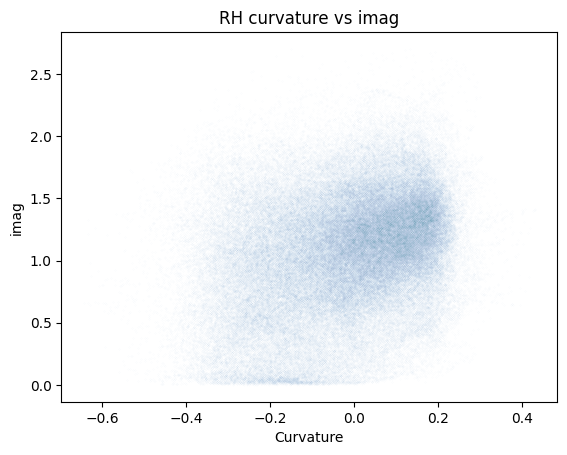

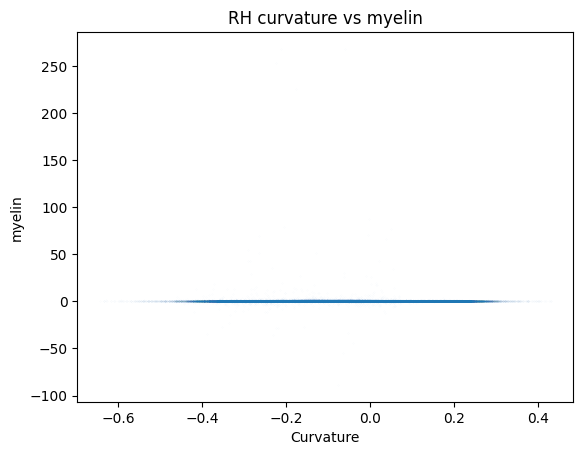

In [64]:
for hemi in ["lh","rh"]:
    for prop in ["stiffness","real","imag","myelin"]:
        plt.scatter(df["curvature"], df[prop], s=0.0001)
        plt.xlabel("Curvature")
        plt.ylabel(prop)
        plt.title (f"{hemi.upper()} curvature vs {prop}")
        plt.show()

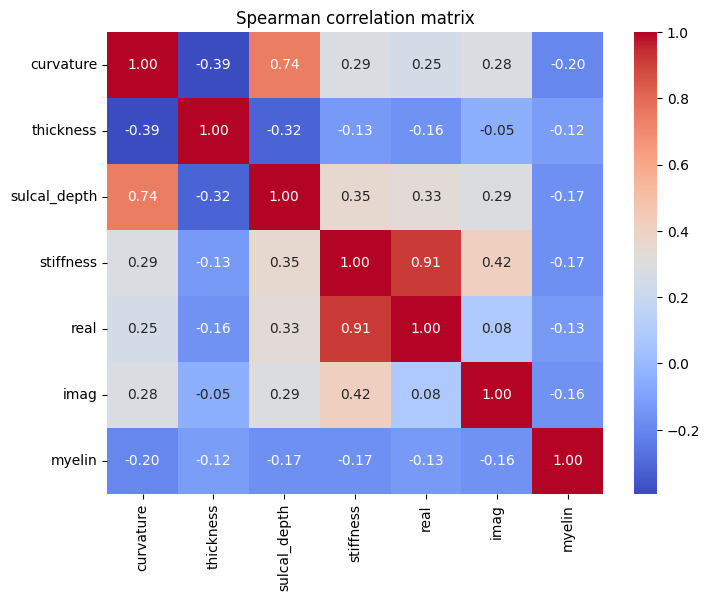

In [54]:
import seaborn as sns

corr_s =df.corr(method="spearman")
plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman correlation matrix")
plt.show()


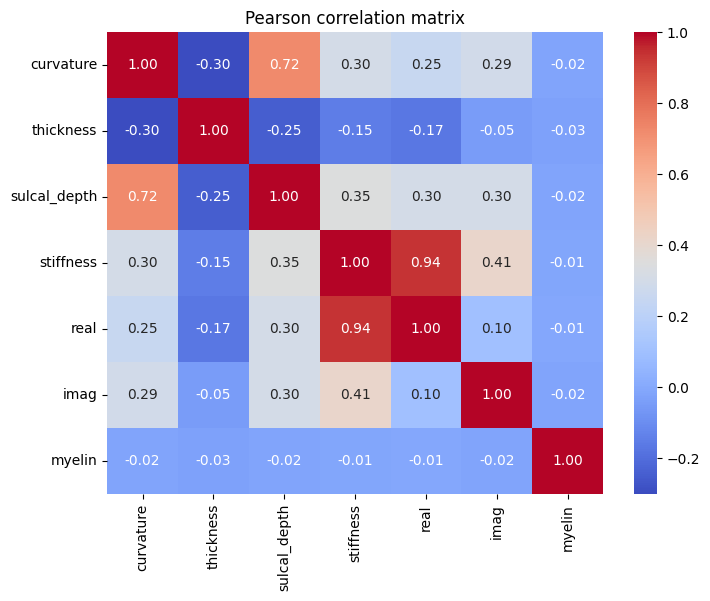

In [55]:
corr_p =df.corr(method="pearson")
plt.figure(figsize=(8,6))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson correlation matrix")
plt.show()

In [38]:
from scipy.stats import pearsonr, spearmanr

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}
    for prop in ["stiffness", "real", "imag","myelin"]:
        #Curvature
        r_p, p_p =pearsonr(df[prop], df["curvature"])
        r_s, p_s =spearmanr(df[prop], df["curvature"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs curvature \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")

        #Thickness

        r_p, p_p =pearsonr(df[prop], df["thickness"])
        r_s, p_s =spearmanr(df[prop], df["thickness"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs thicnkess \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



        r_p, p_p =pearsonr(df[prop], df["sulcal_depth"])
        r_s, p_s =spearmanr(df[prop], df["sulcal_depth"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs sulcal depth \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



LH stiffness vs curvature 
 Pearson r=0.302, p=0.00e+00 
 Spearman r=0.287, p=0.00e+00
LH stiffness vs thicnkess 
 Pearson r=-0.152, p=0.00e+00 
 Spearman r=-0.130, p=0.00e+00
LH stiffness vs sulcal depth 
 Pearson r=0.348, p=0.00e+00 
 Spearman r=0.353, p=0.00e+00
LH real vs curvature 
 Pearson r=0.249, p=0.00e+00 
 Spearman r=0.251, p=0.00e+00
LH real vs thicnkess 
 Pearson r=-0.169, p=0.00e+00 
 Spearman r=-0.158, p=0.00e+00
LH real vs sulcal depth 
 Pearson r=0.300, p=0.00e+00 
 Spearman r=0.325, p=0.00e+00
LH imag vs curvature 
 Pearson r=0.290, p=0.00e+00 
 Spearman r=0.283, p=0.00e+00
LH imag vs thicnkess 
 Pearson r=-0.048, p=1.11e-77 
 Spearman r=-0.046, p=1.13e-72
LH imag vs sulcal depth 
 Pearson r=0.304, p=0.00e+00 
 Spearman r=0.292, p=0.00e+00
LH myelin vs curvature 
 Pearson r=-0.020, p=1.69e-14 
 Spearman r=-0.201, p=0.00e+00
LH myelin vs thicnkess 
 Pearson r=-0.031, p=3.99e-33 
 Spearman r=-0.122, p=0.00e+00
LH myelin vs sulcal depth 
 Pearson r=-0.018, p=3.54e-12 
 S

In [112]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: curvature ~ stiffness")
    print(model.summary())


LH hemisphere: curvature ~ stiffness
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                 1.541e+04
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:34:05   Log-Likelihood:                 70126.
No. Observations:              153716   AIC:                        -1.402e+05
Df Residuals:                  153714   BIC:                        -1.402e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

In [56]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     6888.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:57:19   Log-Likelihood:                 75455.
No. Observations:              153716   AIC:                        -1.509e+05
Df Residuals:                  153711   BIC:                        -1.508e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [ ]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: sulcal_depth ~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: sulcal_depth~ stiffness
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                 2.112e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:39:53   Log-Likelihood:            -4.7162e+05
No. Observations:              153716   AIC:                         9.432e+05
Df Residuals:                  153714   BIC:                         9.433e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [48]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: sulcal_depth ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere: sulcal_depth ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     9471.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:47:10   Log-Likelihood:            -4.6458e+05
No. Observations:              153716   AIC:                         9.292e+05
Df Residuals:                  153711   BIC:                         9.292e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [16]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: thickness~ stiffness
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     3629.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:41:54   Log-Likelihood:            -2.0124e+05
No. Observations:              153716   AIC:                         4.025e+05
Df Residuals:                  153714   BIC:                         4.025e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [49]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1875.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:47:43   Log-Likelihood:            -1.9937e+05
No. Observations:              153716   AIC:                         3.988e+05
Df Residuals:                  153711   BIC:                         3.988e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [ ]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     7598.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:56:05   Log-Likelihood:            -1.8361e+05
No. Observations:              153716   AIC:                         3.672e+05
Df Residuals:                  153712   BIC:                         3.673e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [ ]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth","myelin"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth + myelin")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth+myelin
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     5701.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:45:10   Log-Likelihood:            -1.8360e+05
No. Observations:              153716   AIC:                         3.672e+05
Df Residuals:                  153711   BIC:                         3.673e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

### Older results. Descriptive statistics and visualization

In [139]:
import pandas as pd
import numpy as np

hemi = "lh"  

df = pd.DataFrame({
    "curvature": curvature[hemi].astype(np.float64),
    "thickness": thickness[hemi].astype(np.float64),
    "stiffness": surface_mre["stiffness"][hemi].astype(np.float64),
    "real": surface_mre["real"][hemi].astype(np.float64),
    "imag": surface_mre["imag"][hemi].astype(np.float64),
})

#print(df.shape)
df.describe()


,curvature,thickness,stiffness,real,imag
count,158340.000000,158340.000000,158340.000000,158340.000000,158340.000000
mean,-0.026913,2.462159,2733.969891,2310.648664,1058.058201
std,0.163726,0.888901,999.438308,957.082822,500.618187
min,-0.856185,0.000000,-387.364761,-344.785759,-163.104411
25%,-0.149552,2.047178,2256.364115,1797.324940,764.036828
50%,-0.007015,2.547948,2783.598176,2299.206893,1093.252870
75%,0.105609,3.024685,3366.097488,2879.117310,1385.917470
max,0.613034,5.000000,6554.409197,6501.844461,2800.727100


In [140]:
from scipy.stats import describe

desc = describe(df, axis=0)
#print(desc)
pd.DataFrame({
    "mean": desc.mean,
    "variance": desc.variance,
    "min": desc.minmax[0],
    "max": desc.minmax[1],
    "skewness": desc.skewness,
    "kurtosis": desc.kurtosis,
}, index=df.columns)



,mean,variance,min,max,skewness,kurtosis
curvature,-0.026913,0.026806,-0.856185,0.613034,-0.366335,-0.622449
thickness,2.462159,0.790145,0.000000,5.000000,-0.854616,1.346626
stiffness,2733.969891,998876.931092,-387.364761,6554.409197,-0.634378,1.146827
real,2310.648664,916007.528274,-344.785759,6501.844461,-0.087688,0.769913
imag,1058.058201,250618.569078,-163.104411,2800.727100,-0.193325,-0.140867


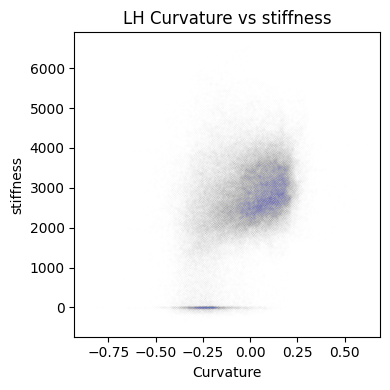

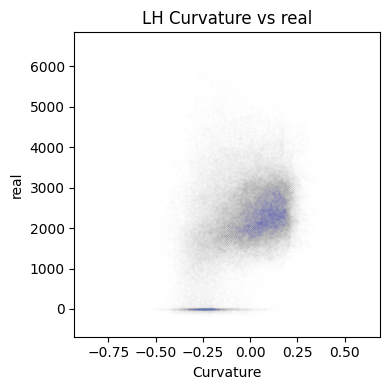

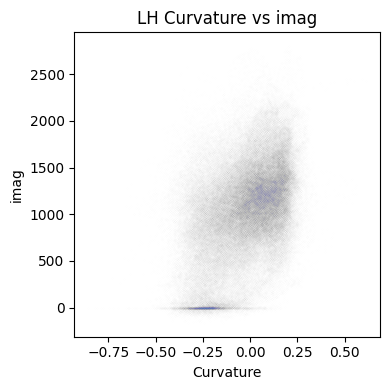

In [141]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["curvature"], df[prop], s=0.0001, alpha=0.3)
    plt.xlabel("Curvature")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Curvature vs {prop}")
    plt.tight_layout()
    plt.show()


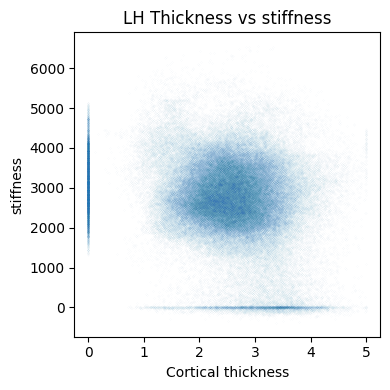

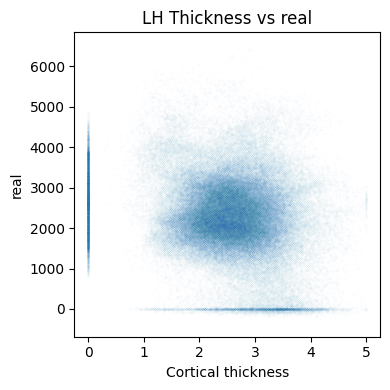

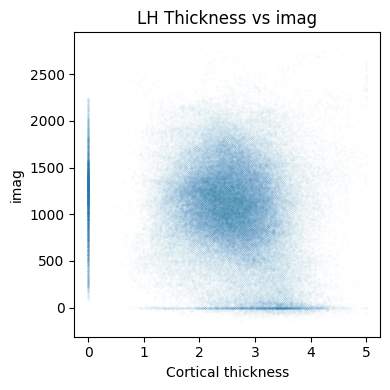

In [142]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["thickness"], df[prop], s=0.001, alpha=0.3)
    plt.xlabel("Cortical thickness")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Thickness vs {prop}")
    plt.tight_layout()
    plt.show()


In [143]:
df.corr(method="spearman")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.379909,0.346424,0.297198,0.394948
thickness,-0.379909,1.000000,-0.165939,-0.159948,-0.160522
stiffness,0.346424,-0.165939,1.000000,0.927095,0.533753
real,0.297198,-0.159948,0.927095,1.000000,0.255344
imag,0.394948,-0.160522,0.533753,0.255344,1.000000


In [144]:
df.corr(method="pearson")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.289677,0.379430,0.310058,0.413114
thickness,-0.289677,1.000000,-0.212827,-0.202171,-0.157003
stiffness,0.379430,-0.212827,1.000000,0.950759,0.585117
real,0.310058,-0.202171,0.950759,1.000000,0.323351
imag,0.413114,-0.157003,0.585117,0.323351,1.000000


### Correlation analysis

In [147]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

#mask = surface_brainmask[hemi]
def clean_pair(x, y):
    mask = (
        np.isfinite(x) &
        np.isfinite(y) 
    )
    #return x[mask], y[mask]
    return x, y

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}

    curv = curvature[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(curv, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e}"
        )


LH | stiffness | N=158340 | Pearson r=0.379, p=0.00e+00 | Spearman r=0.346, p=0.00e+00
LH | real | N=158340 | Pearson r=0.310, p=0.00e+00 | Spearman r=0.297, p=0.00e+00
LH | imag | N=158340 | Pearson r=0.413, p=0.00e+00 | Spearman r=0.395, p=0.00e+00
RH | stiffness | N=159948 | Pearson r=0.368, p=0.00e+00 | Spearman r=0.335, p=0.00e+00
RH | real | N=159948 | Pearson r=0.318, p=0.00e+00 | Spearman r=0.303, p=0.00e+00
RH | imag | N=159948 | Pearson r=0.349, p=0.00e+00 | Spearman r=0.331, p=0.00e+00


In [148]:
# Correlations with thickness
for hemi in ["lh", "rh"]:
    thick = thickness[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(thick, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop + "_thickness"] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e} (thickness)"
        )


LH | stiffness | N=158340 | Pearson r=-0.213, p=0.00e+00 | Spearman r=-0.166, p=0.00e+00 (thickness)
LH | real | N=158340 | Pearson r=-0.202, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
LH | imag | N=158340 | Pearson r=-0.157, p=0.00e+00 | Spearman r=-0.161, p=0.00e+00 (thickness)
RH | stiffness | N=159948 | Pearson r=-0.191, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
RH | real | N=159948 | Pearson r=-0.203, p=0.00e+00 | Spearman r=-0.186, p=0.00e+00 (thickness)
RH | imag | N=159948 | Pearson r=-0.093, p=1.47e-305 | Spearman r=-0.084, p=3.99e-247 (thickness)


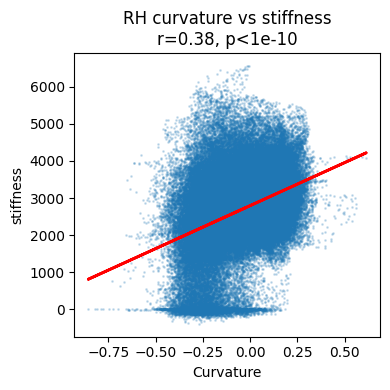

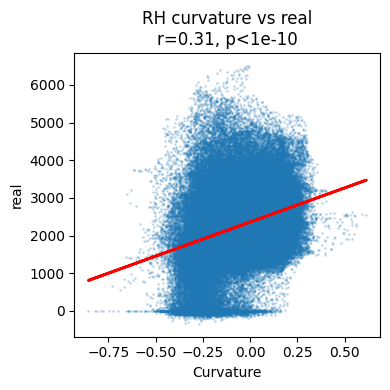

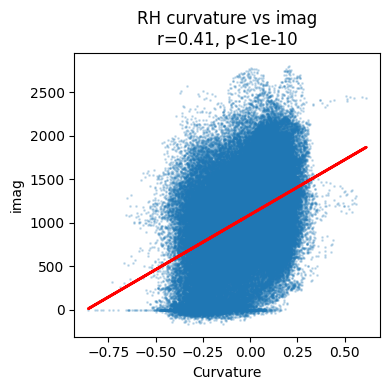

In [149]:
from scipy.stats import linregress

for prop in ["stiffness", "real", "imag"]:
    x = df["curvature"].values
    y = df[prop].values

    slope, intercept, r, p, _ = linregress(x, y)

    plt.figure(figsize=(4,4))
    plt.scatter(x, y, s=1, alpha=0.2)
    plt.plot(x, slope*x + intercept, color="red", linewidth=2)
    plt.xlabel("Curvature")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} curvature vs {prop}\nr={r:.2f}, p<1e-10")
    plt.tight_layout()
    plt.show()


In [150]:
import statsmodels.api as sm

def regression_summary(x, y, xlabel, ylabel):
    # Clean data
    mask = np.isfinite(x) & np.isfinite(y) & (x != 0) & (y != 0)
    x_clean = x[mask]
    y_clean = y[mask]

    X = sm.add_constant(x_clean)  # Add intercept term
    model = sm.OLS(y_clean, X).fit()  # Ordinary Least Squares regression
    print(f"{ylabel} vs {xlabel}")
    print(model.summary())  # Full regression table
    print("\n")

# Loop over hemispheres and properties
for hemi in ["lh", "rh"]:
    for prop in ["stiffness", "real", "imag"]:
        print(f"{hemi.upper()}")
        # Regression with curvature
        regression_summary(curvature[hemi], surface_mre[prop][hemi], "Curvature", prop)
        # Regression with thickness
        regression_summary(thickness[hemi], surface_mre[prop][hemi], "Thickness", prop)


LH
stiffness vs Curvature
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                 2.663e+04
Date:                Fri, 13 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:36:45   Log-Likelihood:            -1.3061e+06
No. Observations:              158340   AIC:                         2.612e+06
Df Residuals:                  158338   BIC:                         2.612e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2796.3039     